# 1. Perkenalan Dataset

Dataset yang digunakan adalah **Titanic Dataset** yang diperoleh dari Kaggle.

- **Sumber**: Kaggle (Titanic - Machine Learning from Disaster)
- **Jumlah data**: 891 baris, 12 kolom
- **Target**: Survived (0 = tidak selamat, 1 = selamat)
- **Task**: Binary Classification

# 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline

print('Library berhasil diimport!')

Library berhasil diimport!


# 3. Memuat Dataset

In [2]:
df = pd.read_csv('../titanic_raw/Titanic-Dataset.csv')

print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
df.head()

Shape: (891, 12)
Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. Exploratory Data Analysis (EDA)

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).query('`Missing Count` > 0')
print(missing_df)

          Missing Count  Missing (%)
Age                 177        19.87
Cabin               687        77.10
Embarked              2         0.22


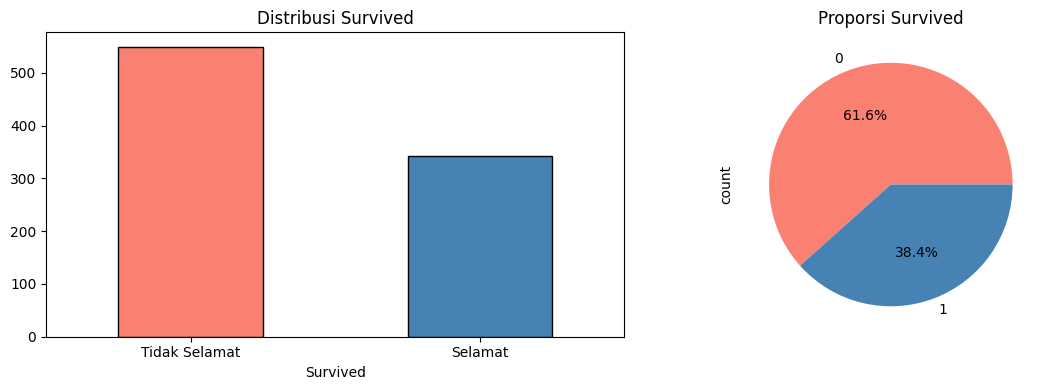

In [6]:
# Distribusi target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='black')
axes[0].set_title('Distribusi Survived')
axes[0].set_xticklabels(['Tidak Selamat', 'Selamat'], rotation=0)

df['Survived'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['salmon', 'steelblue'])
axes[1].set_title('Proporsi Survived')

plt.tight_layout()
plt.show()

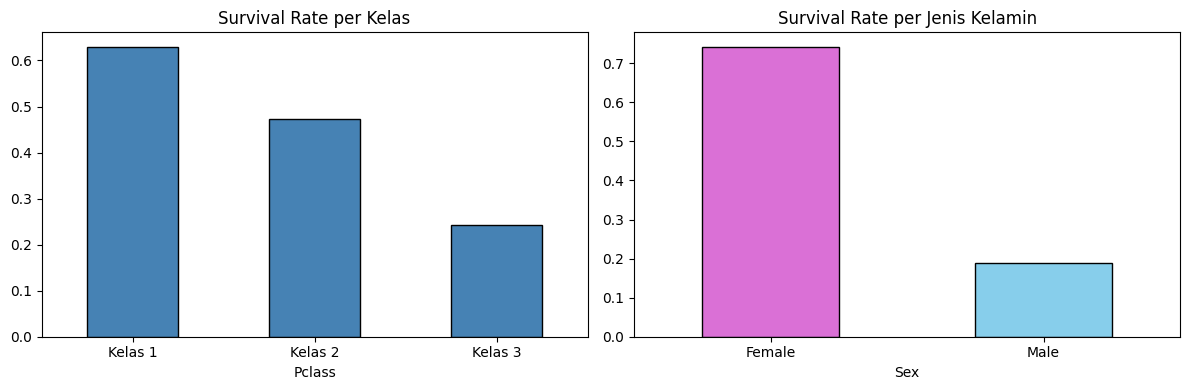

In [7]:
# Survival rate by Pclass dan Sex
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Survival Rate per Kelas')
axes[0].set_xticklabels(['Kelas 1', 'Kelas 2', 'Kelas 3'], rotation=0)

df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['orchid', 'skyblue'], edgecolor='black')
axes[1].set_title('Survival Rate per Jenis Kelamin')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

plt.tight_layout()
plt.show()

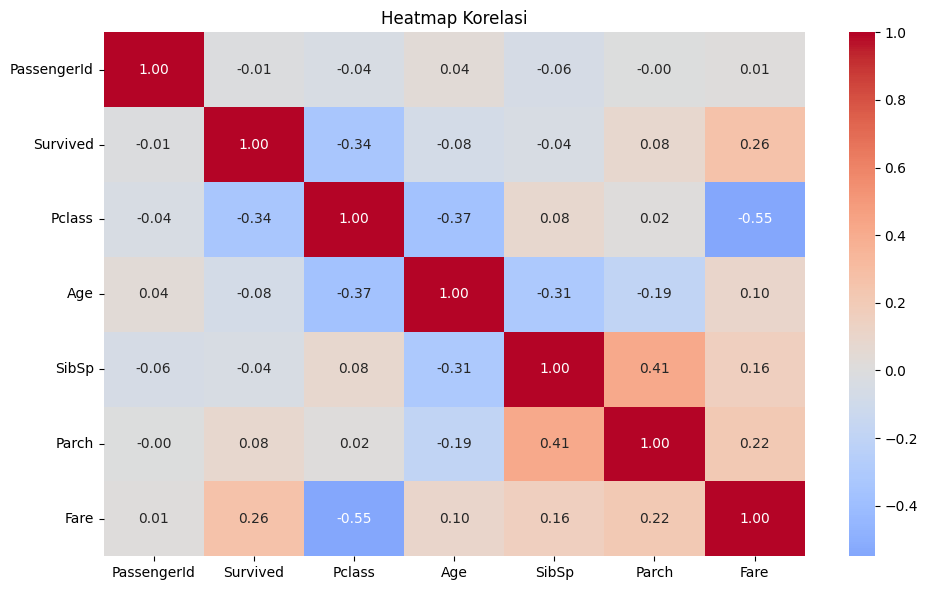

In [8]:
# Heatmap korelasi
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

In [9]:
# Drop kolom tidak relevan
df_processed = df.copy()
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_processed = df_processed.drop(columns=cols_to_drop)
print(f'Shape setelah drop: {df_processed.shape}')

Shape setelah drop: (891, 8)


In [10]:
# Handle missing values
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())
df_processed['Embarked'] = df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0])
print(f'Missing values: {df_processed.isnull().sum().sum()}')

Missing values: 0


In [11]:
# Feature engineering
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
print('FamilySize dan IsAlone berhasil dibuat!')

FamilySize dan IsAlone berhasil dibuat!


In [12]:
# Encoding
le = LabelEncoder()
df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
df_processed['Embarked'] = le.fit_transform(df_processed['Embarked'])
print('Encoding selesai!')
df_processed.head()

Encoding selesai!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,0
2,1,3,0,26.0,0,0,7.9250,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0
4,0,3,1,35.0,0,0,8.0500,2,1,1


In [13]:
# Scaling
scaler = StandardScaler()
num_cols = ['Age', 'Fare', 'FamilySize']
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])
print('Scaling selesai!')

Scaling selesai!


In [14]:
# Train-test split
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (712, 9), X_test: (179, 9)


In [15]:
# Simpan hasil preprocessing
os.makedirs('titanic_preprocessing', exist_ok=True)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv('titanic_preprocessing/train.csv', index=False)
test_data.to_csv('titanic_preprocessing/test.csv', index=False)

print('Data preprocessing tersimpan!')
print(f'Train: {train_data.shape}, Test: {test_data.shape}')

Data preprocessing tersimpan!
Train: (712, 10), Test: (179, 10)
